This notebook is to gather indivudual results from the comet log file for different scenarios for all methods.

In [28]:
import sys
import comet_ml
comet_ml.login()
from comet_ml import API, Experiment
sys.path.append(".")
from utils import *
from tqdm import tqdm

In [29]:
workspace = "b-acharya"  # Replace with your Comet workspace name

#this is different for each project
project_name = "exp2-public-on-cmbp-start2"  # Replace with your project name

api = API()

In [30]:
experiments = api.get_experiments(workspace=workspace, project_name=project_name)

In [31]:
len(experiments)

12

# CMBP

In [32]:
#COHFACE and differnt models
from collections import OrderedDict
models = OrderedDict([])

for experiment in tqdm(experiments):
    experiment_name = experiment.name
    
    if "PhysFormer" in experiment_name:
        continue
    
    tqdm.write(f"Experiment Name: {experiment.name}")  # Print without breaking the progress bar
    models[experiment_name] = [experiment]

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 12/12 [00:00<00:00, 795.64it/s]

Experiment Name: PURE_CMBP_DeepPhys
Experiment Name: PURE_CMBP_Tscan
Experiment Name: PURE_CMBP_Physnet
Experiment Name: COHFACE_CMBP_DeepPhys
Experiment Name: COHFACE_CMBP_Tscan
Experiment Name: COHFACE_CMBP_Physnet
Experiment Name: COHFACE_CMBP_rPPGNet
Experiment Name: PURE_CMBP_rPPGNet


In [33]:
models

OrderedDict([('PURE_CMBP_DeepPhys',
              [<APIExperiment 'b-acharya/exp2-public-on-cmbp-start2/d68a13b6aafd43ae9b63c85894e6463e'>]),
             ('PURE_CMBP_Tscan',
              [<APIExperiment 'b-acharya/exp2-public-on-cmbp-start2/2e8aed9d39714dbea8d756d3fe5787d3'>]),
             ('PURE_CMBP_Physnet',
              [<APIExperiment 'b-acharya/exp2-public-on-cmbp-start2/16ea2554e1c84b63a2b5c4408f141ac5'>]),
             ('COHFACE_CMBP_DeepPhys',
              [<APIExperiment 'b-acharya/exp2-public-on-cmbp-start2/becdc37d8e2149eba0d1991bd7b46a95'>]),
             ('COHFACE_CMBP_Tscan',
              [<APIExperiment 'b-acharya/exp2-public-on-cmbp-start2/c56f354c16624216bc58dd3f20455b3e'>]),
             ('COHFACE_CMBP_Physnet',
              [<APIExperiment 'b-acharya/exp2-public-on-cmbp-start2/ace6adc90da24e1790cb24182160ff6b'>]),
             ('COHFACE_CMBP_rPPGNet',
              [<APIExperiment 'b-acharya/exp2-public-on-cmbp-start2/caa25f10d5b54d6f94845349b3a672e1'>]),
   

In [34]:
model_dataframes = OrderedDict()

for model_name, experiments in models.items():
    print(model_name, experiments)
    model_dataframes[model_name] = get_dataframe(experiments)

# deepPhys_CMBP_df = get_dataframe(CMBP_deepphys_experiments)

# tscan_CMBP_df = get_dataframe(CMBP_tscan_experiments)

# physnet_CMBP_df = get_dataframe(CMBP_physnet_experiments)

# rppgnet_CMBP_df = get_dataframe(CMBP_rppgnet_experiments)


PURE_CMBP_DeepPhys [<APIExperiment 'b-acharya/exp2-public-on-cmbp-start2/d68a13b6aafd43ae9b63c85894e6463e'>]
PURE_CMBP_Tscan [<APIExperiment 'b-acharya/exp2-public-on-cmbp-start2/2e8aed9d39714dbea8d756d3fe5787d3'>]
PURE_CMBP_Physnet [<APIExperiment 'b-acharya/exp2-public-on-cmbp-start2/16ea2554e1c84b63a2b5c4408f141ac5'>]
COHFACE_CMBP_DeepPhys [<APIExperiment 'b-acharya/exp2-public-on-cmbp-start2/becdc37d8e2149eba0d1991bd7b46a95'>]
COHFACE_CMBP_Tscan [<APIExperiment 'b-acharya/exp2-public-on-cmbp-start2/c56f354c16624216bc58dd3f20455b3e'>]
COHFACE_CMBP_Physnet [<APIExperiment 'b-acharya/exp2-public-on-cmbp-start2/ace6adc90da24e1790cb24182160ff6b'>]
COHFACE_CMBP_rPPGNet [<APIExperiment 'b-acharya/exp2-public-on-cmbp-start2/caa25f10d5b54d6f94845349b3a672e1'>]
PURE_CMBP_rPPGNet [<APIExperiment 'b-acharya/exp2-public-on-cmbp-start2/1fd1ac9251d44fa980fce8e8f3a4f17c'>]


In [35]:
for model_name, df in model_dataframes.items():
    print(len(df))

180
180
180
180
180
180
180
180


In [36]:
model_dataframes[model_name]

GT_HR    Pred_HR      Error
FOLD Participant-ID                                  
t    0_AY31324245_0   84.228516  71.044922  13.183594
     0_AY31324245_1   82.763672  93.750000  10.986328
     0_AY31324245_2   80.566406  93.750000  13.183594
     0_AY31324245_3   91.552734  71.044922  20.507812
     0_CC36214245_0  110.595703  71.044922  39.550781
...                         ...        ...        ...
     0_VM20214245_3   84.960938  71.044922  13.916016
     0_VR35324245_0   68.847656  71.044922   2.197266
     0_VR35324245_1   69.580078  93.750000  24.169922
     0_VR35324245_2   83.496094  93.750000  10.253906
     0_VR35324245_3   82.763672  71.044922  11.718750

[180 rows x 3 columns]

In [19]:

fold_CMBP_mae_deepphys_df = deepPhys_CMBP_df.groupby('FOLD')['Error'].mean()
fold_CMBP_mae_tscan_df = tscan_CMBP_df.groupby('FOLD')['Error'].mean()
fold_CMBP_mae_physnet_df = physnet_CMBP_df.groupby('FOLD')['Error'].mean()
fold_CMBP_mae_rppgnet_df = rppgnet_CMBP_df.groupby('FOLD')['Error'].mean()

print(fold_CMBP_mae_deepphys_df.mean())
print(fold_CMBP_mae_tscan_df.mean())
print(fold_CMBP_mae_physnet_df.mean())
print(fold_CMBP_mae_rppgnet_df.mean())

NameError: name 'deepPhys_CMBP_df' is not defined

In [37]:
def modify_datafram_CMBP(df):
    df.reset_index(inplace=True)
    df['scenario'] = df['Participant-ID'].str[-1:].astype(int)
    df['Participant'] = df['Participant-ID'].str[2:-2]
    return df

for model_name, df in model_dataframes.items():
    print(model_name)
    model_dataframes[model_name] = modify_datafram_CMBP(df)


PURE_CMBP_DeepPhys
PURE_CMBP_Tscan
PURE_CMBP_Physnet
COHFACE_CMBP_DeepPhys
COHFACE_CMBP_Tscan
COHFACE_CMBP_Physnet
COHFACE_CMBP_rPPGNet
PURE_CMBP_rPPGNet


In [38]:
model_dataframes[model_name]

,FOLD,Participant-ID,GT_HR,Pred_HR,Error,scenario,Participant
0,t,0_AY31324245_0,84.228516,71.044922,13.183594,0,AY31324245
1,t,0_AY31324245_1,82.763672,93.750000,10.986328,1,AY31324245
2,t,0_AY31324245_2,80.566406,93.750000,13.183594,2,AY31324245
3,t,0_AY31324245_3,91.552734,71.044922,20.507812,3,AY31324245
4,t,0_CC36214245_0,110.595703,71.044922,39.550781,0,CC36214245
...,...,...,...,...,...,...,...
175,t,0_VM20214245_3,84.960938,71.044922,13.916016,3,VM20214245
176,t,0_VR35324245_0,68.847656,71.044922,2.197266,0,VR35324245
177,t,0_VR35324245_1,69.580078,93.750000,24.169922,1,VR35324245
178,t,0_VR35324245_2,83.496094,93.750000,10.253906,2,VR35324245


----------
# Resutls

PURE_CMBP_DeepPhys
using chill dataset
defining scenarios
This is performed on illumination splits


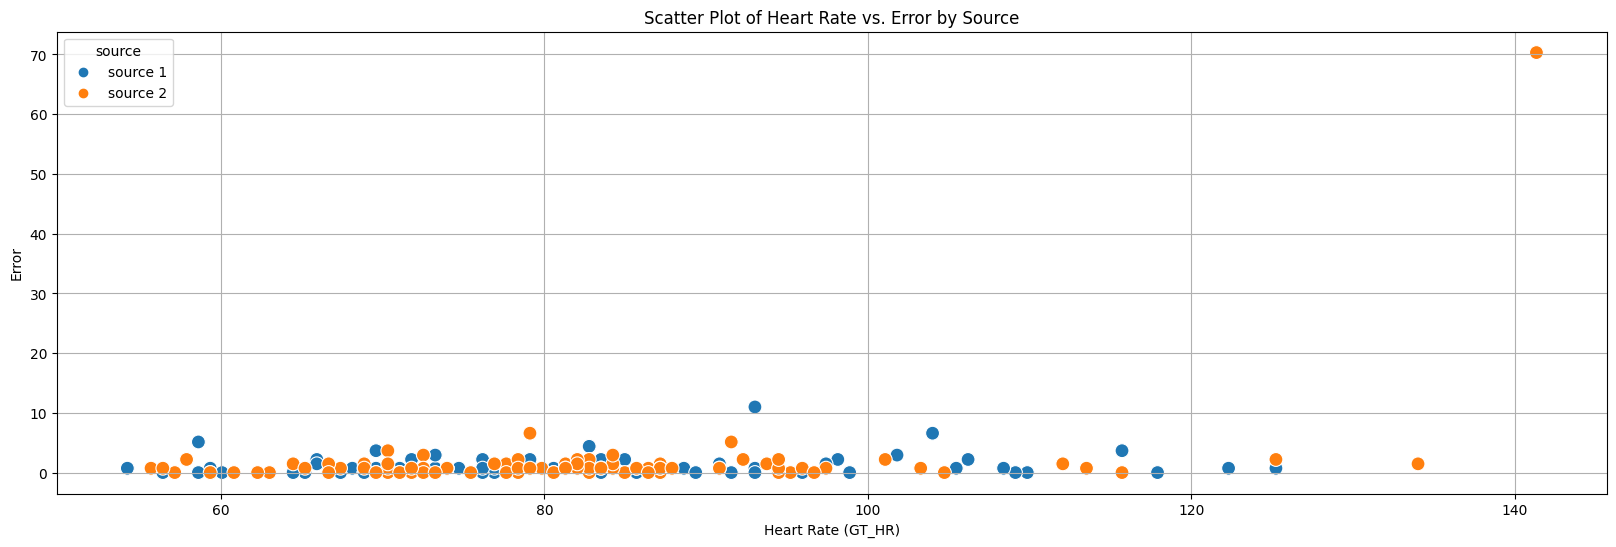

No. of Participants in dataset:  45


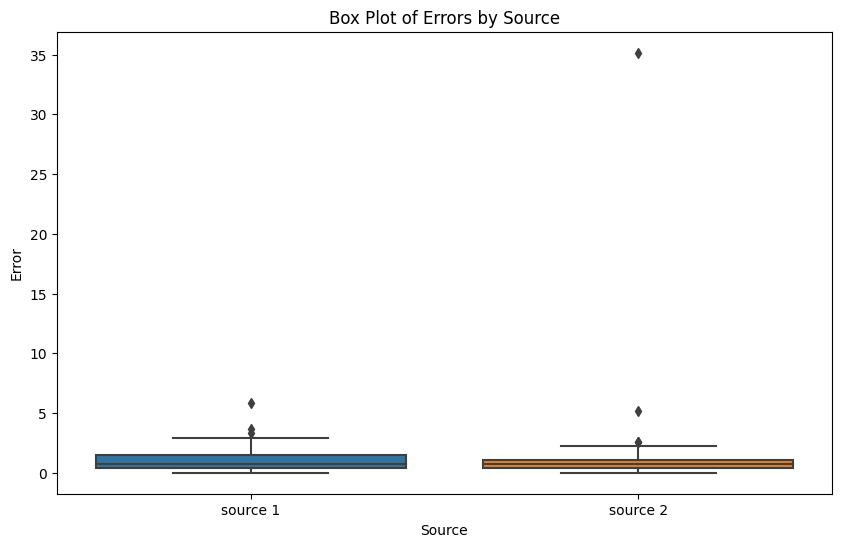

No significant difference detected between scenarios.
PURE_CMBP_Tscan
using chill dataset
defining scenarios
This is performed on illumination splits


/Users/bhargavacharya/miniconda3/envs/stats/lib/python3.10/site-packages/seaborn/_core.py:1462: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/Users/bhargavacharya/miniconda3/envs/stats/lib/python3.10/site-packages/seaborn/_core.py:1462: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/Users/bhargavacharya/miniconda3/envs/stats/lib/python3.10/site-packages/seaborn/_core.py:1462: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


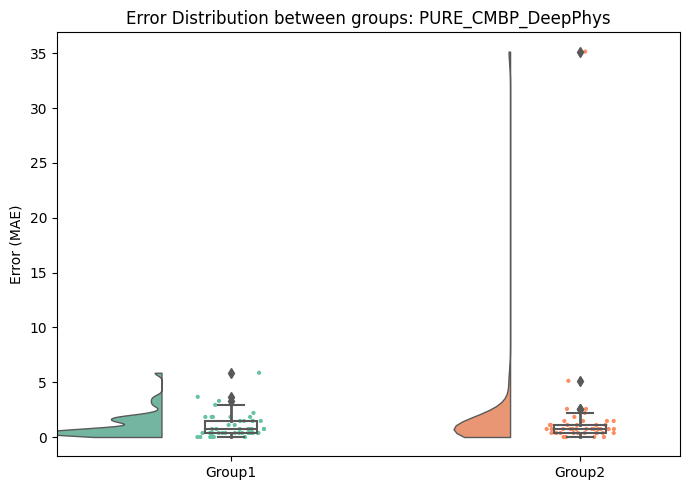

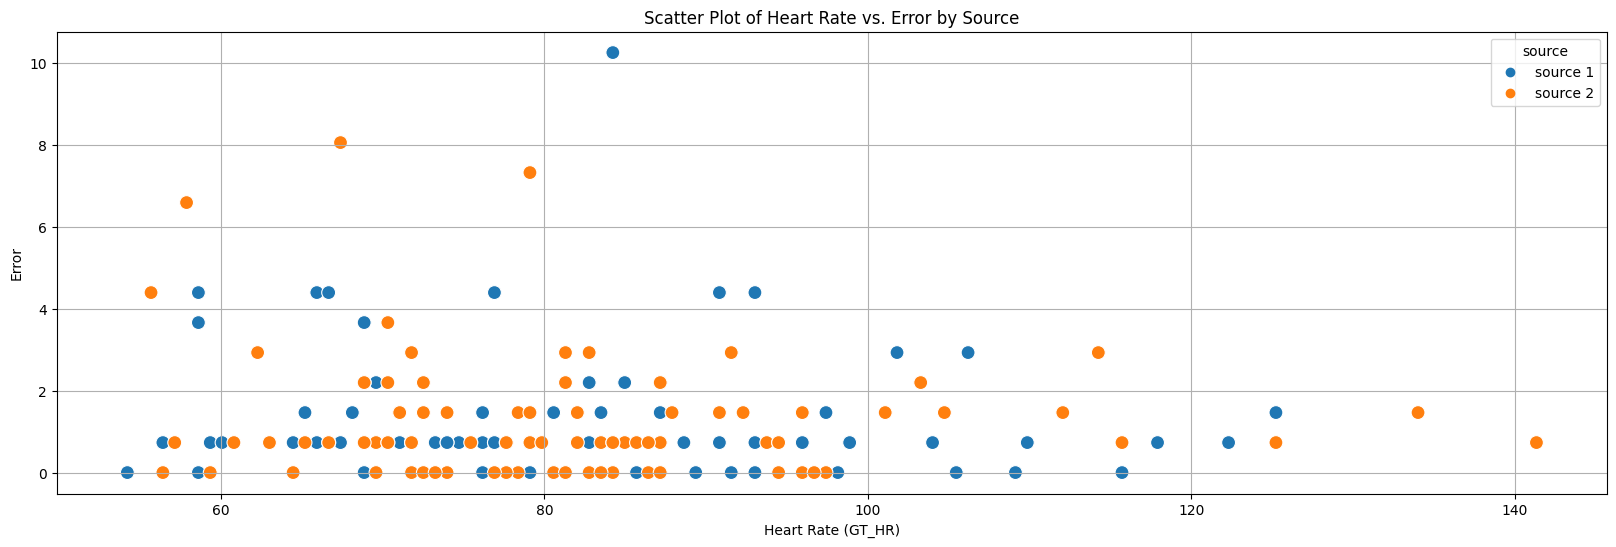

No. of Participants in dataset:  45


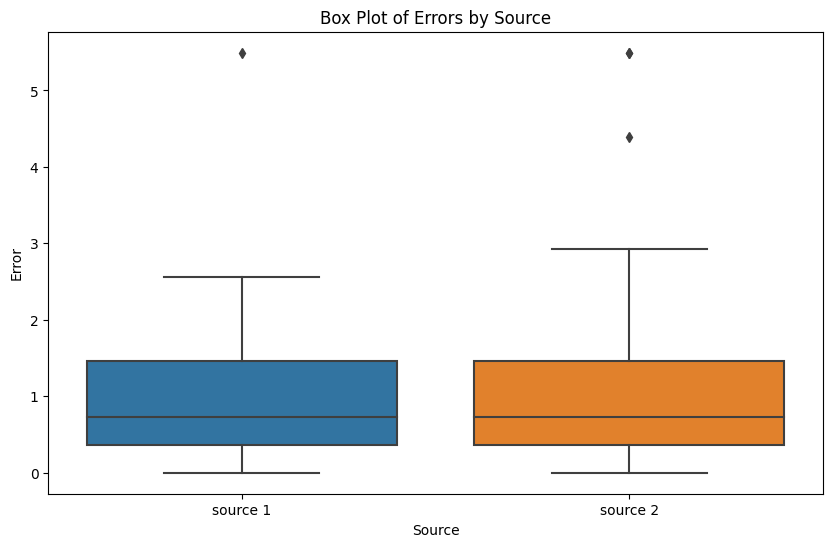

No significant difference detected between scenarios.
PURE_CMBP_Physnet
using chill dataset
defining scenarios
This is performed on illumination splits


/Users/bhargavacharya/miniconda3/envs/stats/lib/python3.10/site-packages/seaborn/_core.py:1462: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/Users/bhargavacharya/miniconda3/envs/stats/lib/python3.10/site-packages/seaborn/_core.py:1462: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/Users/bhargavacharya/miniconda3/envs/stats/lib/python3.10/site-packages/seaborn/_core.py:1462: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


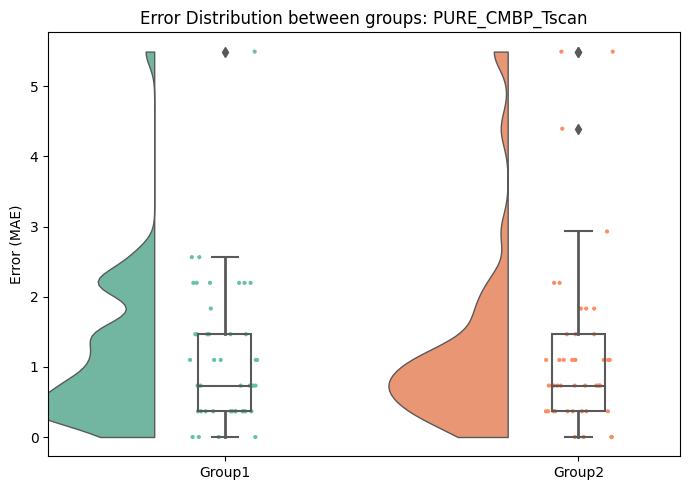

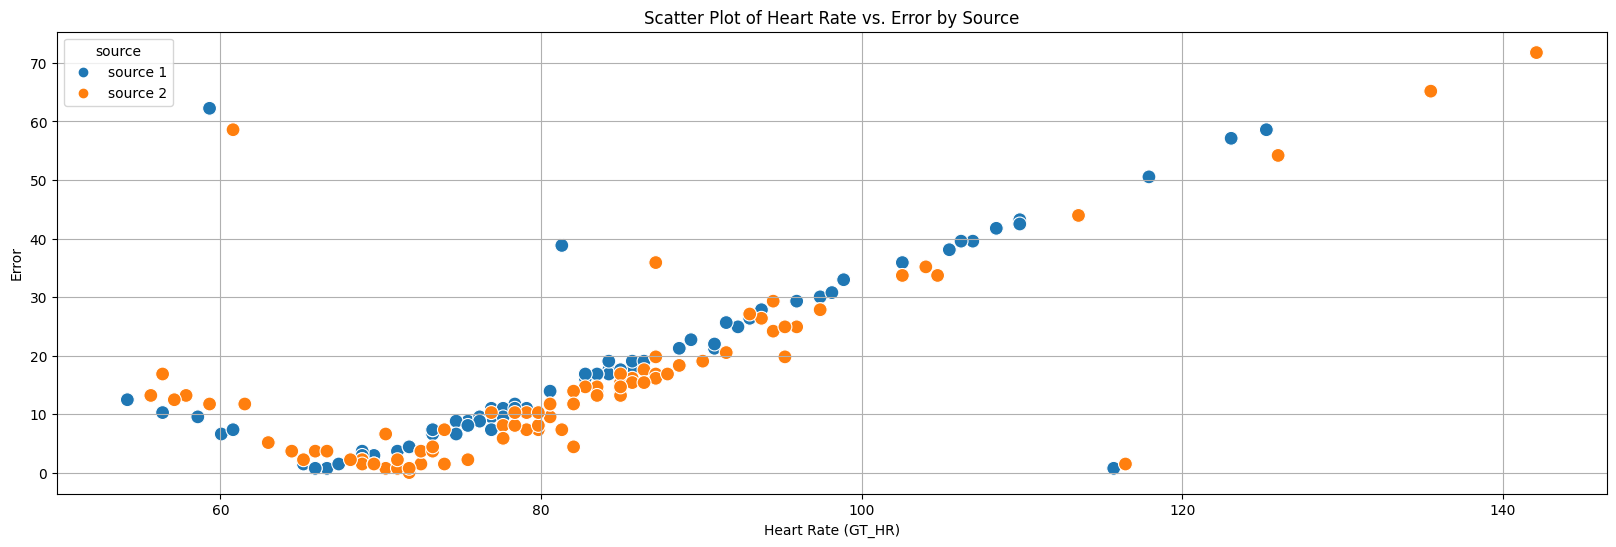

No. of Participants in dataset:  45


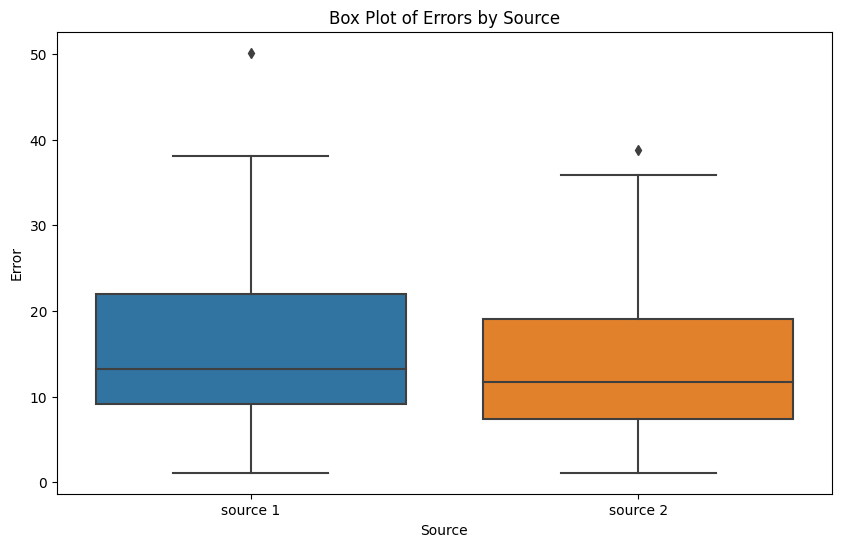

Can use Paired t-test
No significant difference detected between scenarios.
COHFACE_CMBP_DeepPhys
using chill dataset
defining scenarios
This is performed on illumination splits


/Users/bhargavacharya/miniconda3/envs/stats/lib/python3.10/site-packages/seaborn/_core.py:1462: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/Users/bhargavacharya/miniconda3/envs/stats/lib/python3.10/site-packages/seaborn/_core.py:1462: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/Users/bhargavacharya/miniconda3/envs/stats/lib/python3.10/site-packages/seaborn/_core.py:1462: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


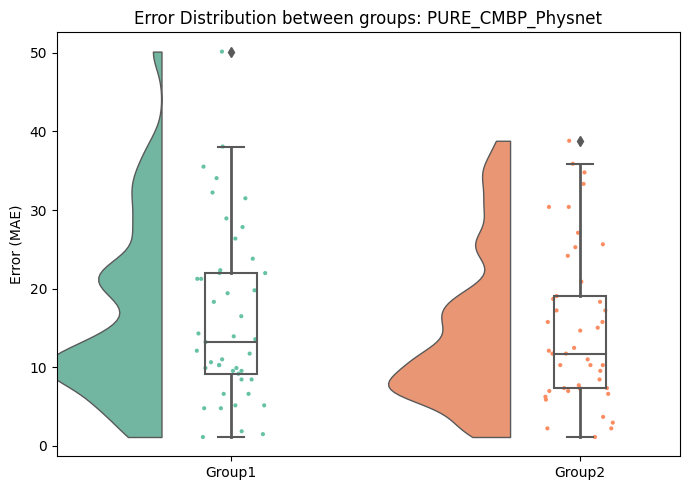

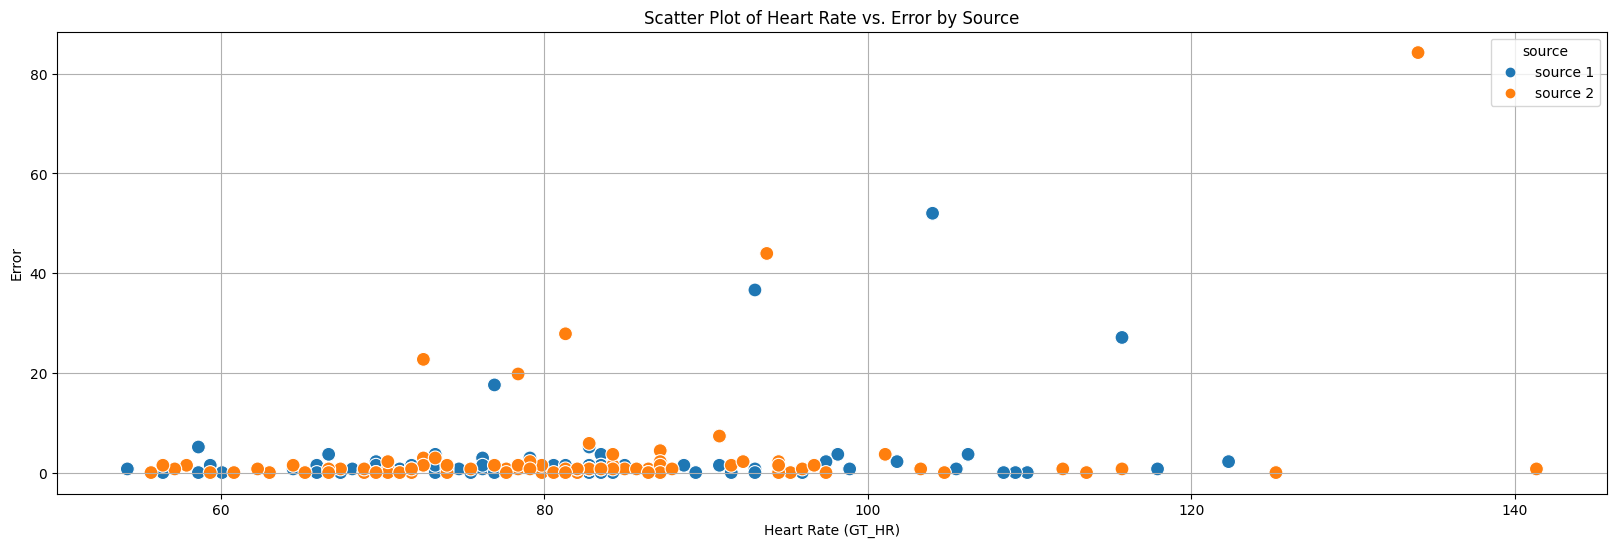

No. of Participants in dataset:  45


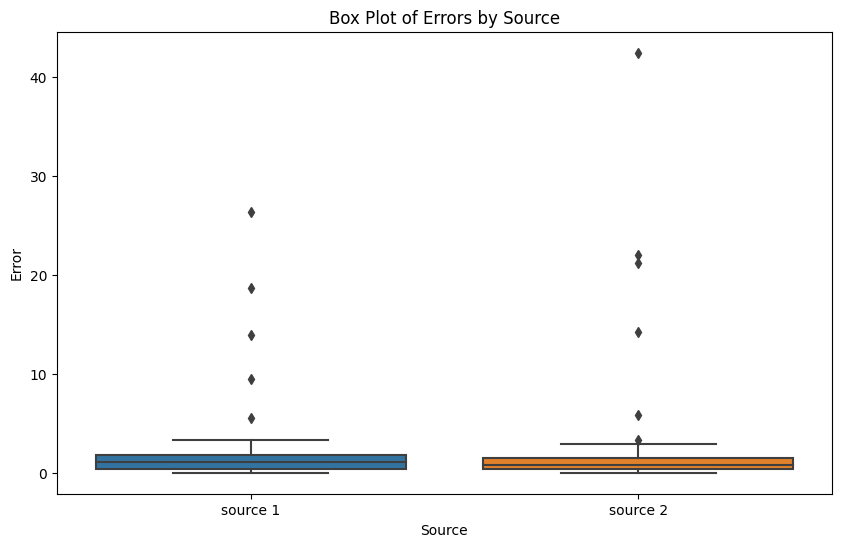

No significant difference detected between scenarios.
COHFACE_CMBP_Tscan
using chill dataset
defining scenarios
This is performed on illumination splits


/Users/bhargavacharya/miniconda3/envs/stats/lib/python3.10/site-packages/seaborn/_core.py:1462: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/Users/bhargavacharya/miniconda3/envs/stats/lib/python3.10/site-packages/seaborn/_core.py:1462: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/Users/bhargavacharya/miniconda3/envs/stats/lib/python3.10/site-packages/seaborn/_core.py:1462: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


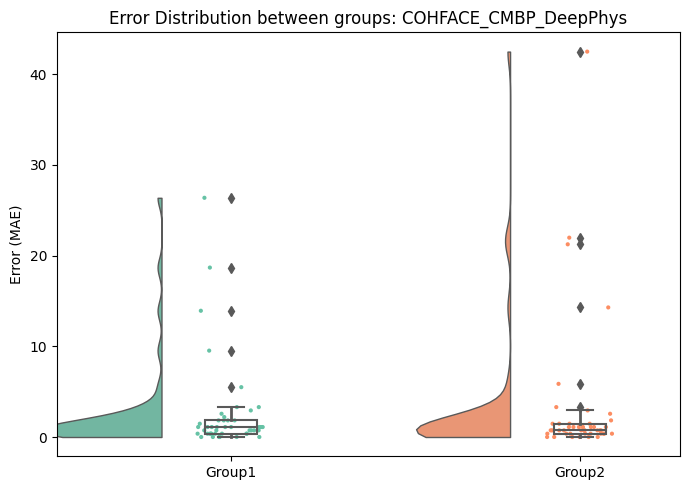

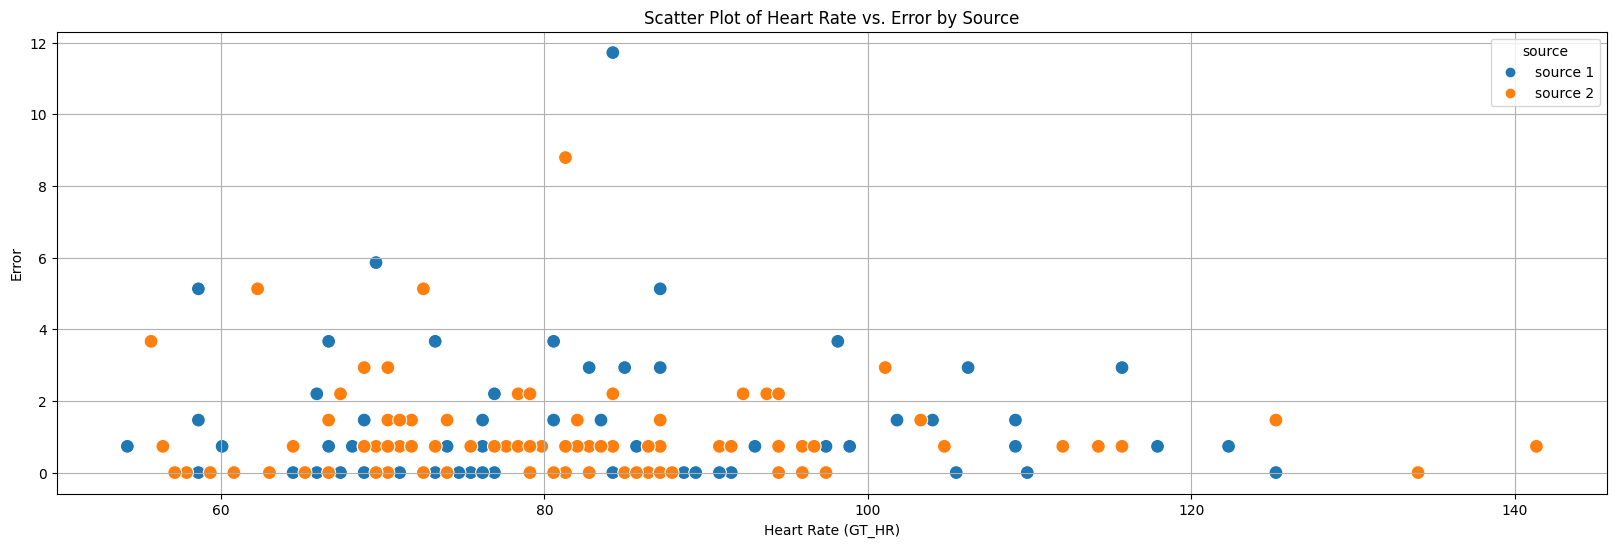

No. of Participants in dataset:  45


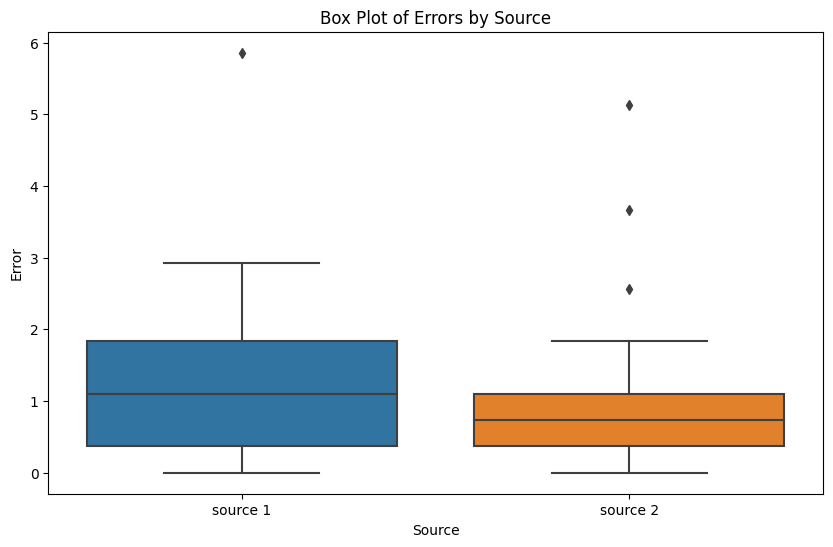

No significant difference detected between scenarios.
COHFACE_CMBP_Physnet
using chill dataset
defining scenarios
This is performed on illumination splits


/Users/bhargavacharya/miniconda3/envs/stats/lib/python3.10/site-packages/seaborn/_core.py:1462: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/Users/bhargavacharya/miniconda3/envs/stats/lib/python3.10/site-packages/seaborn/_core.py:1462: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/Users/bhargavacharya/miniconda3/envs/stats/lib/python3.10/site-packages/seaborn/_core.py:1462: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


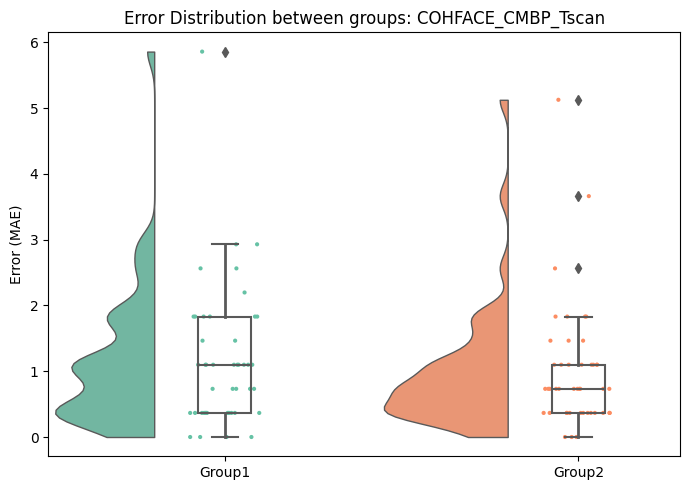

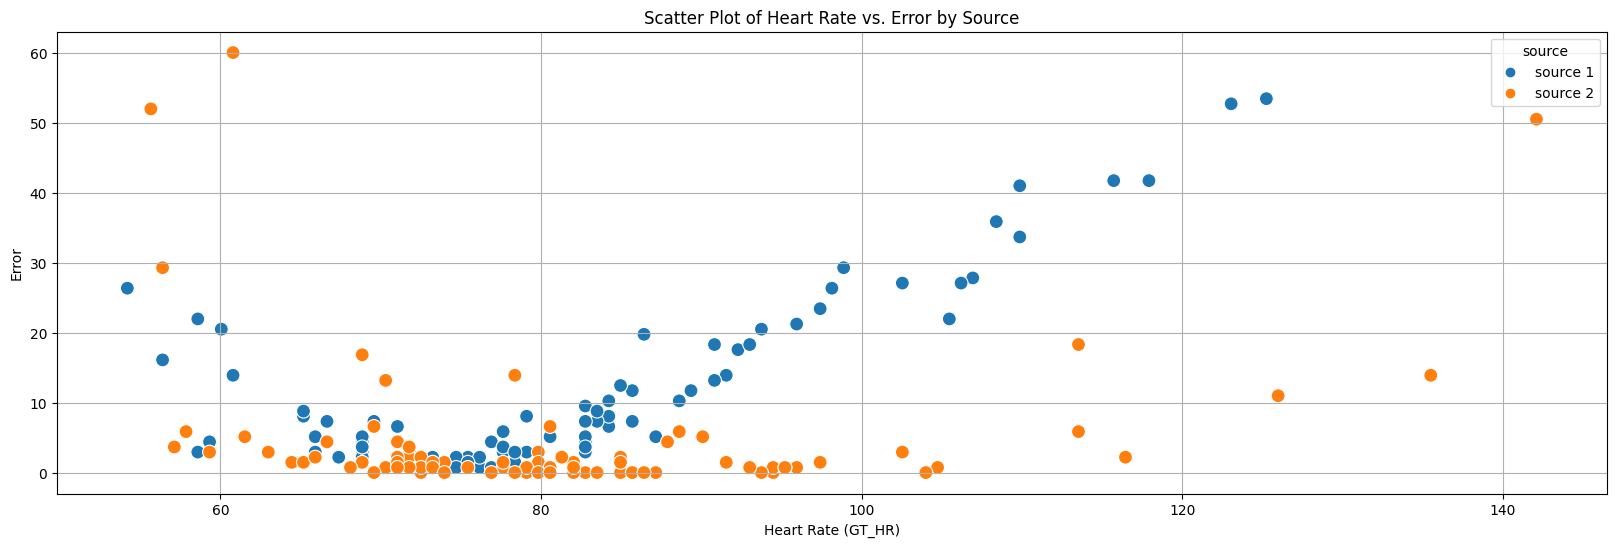

No. of Participants in dataset:  45


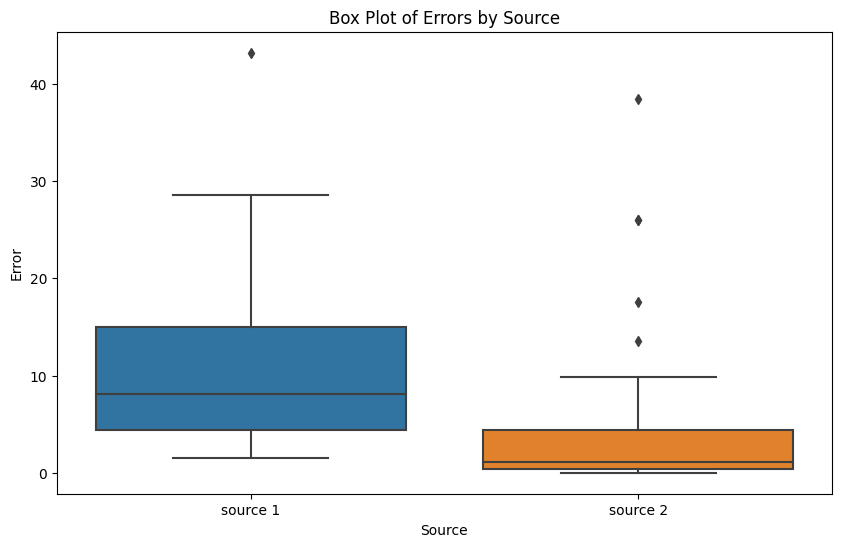

Significant difference detected between scenarios!
COHFACE_CMBP_rPPGNet
using chill dataset
defining scenarios
This is performed on illumination splits


/Users/bhargavacharya/miniconda3/envs/stats/lib/python3.10/site-packages/seaborn/_core.py:1462: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/Users/bhargavacharya/miniconda3/envs/stats/lib/python3.10/site-packages/seaborn/_core.py:1462: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/Users/bhargavacharya/miniconda3/envs/stats/lib/python3.10/site-packages/seaborn/_core.py:1462: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


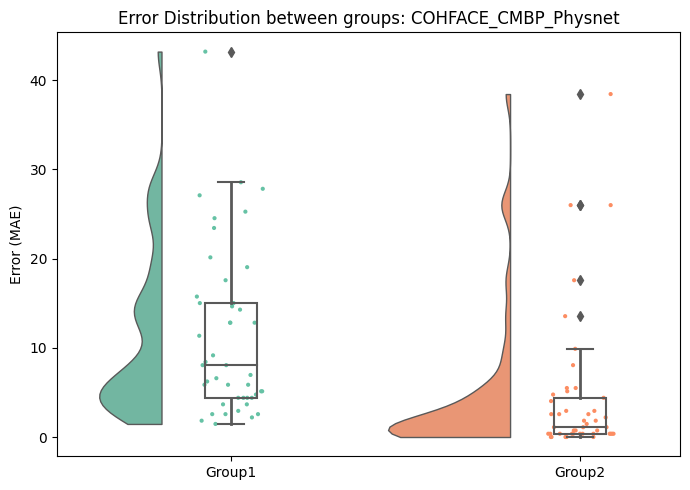

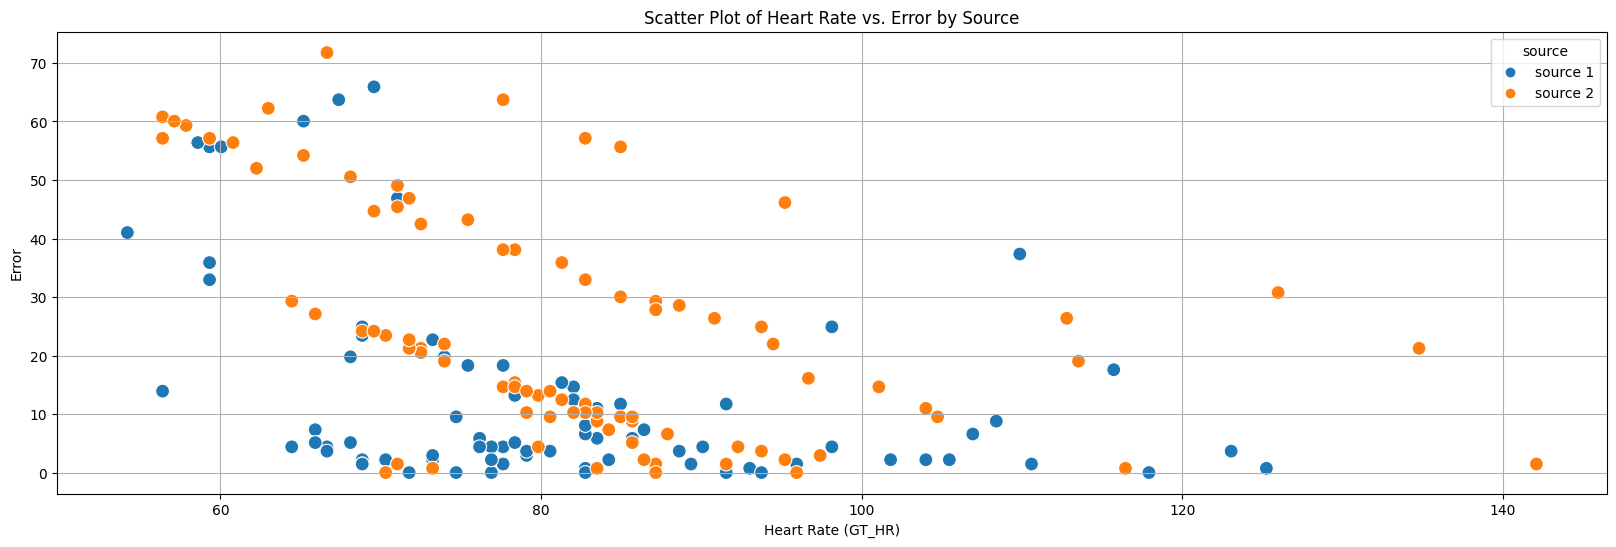

No. of Participants in dataset:  45


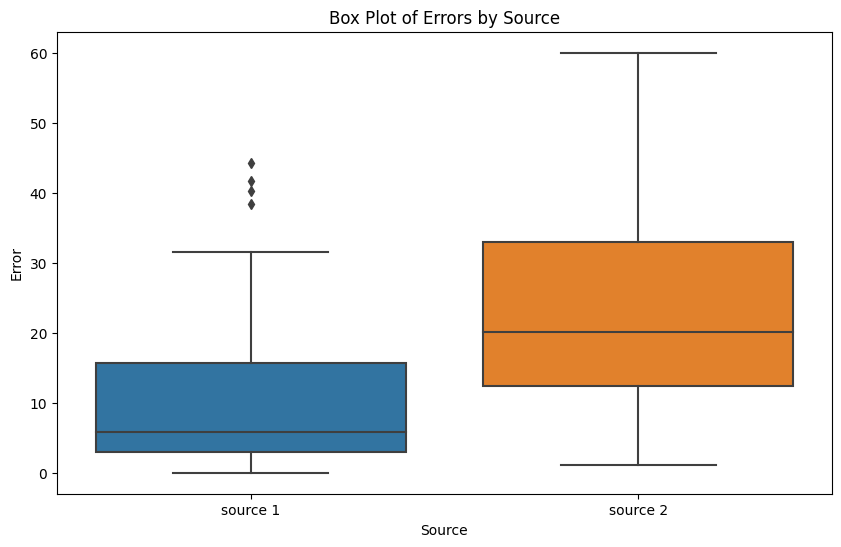

Can use Paired t-test
Significant difference detected between scenarios!
PURE_CMBP_rPPGNet
using chill dataset
defining scenarios
This is performed on illumination splits


/Users/bhargavacharya/miniconda3/envs/stats/lib/python3.10/site-packages/seaborn/_core.py:1462: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/Users/bhargavacharya/miniconda3/envs/stats/lib/python3.10/site-packages/seaborn/_core.py:1462: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/Users/bhargavacharya/miniconda3/envs/stats/lib/python3.10/site-packages/seaborn/_core.py:1462: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


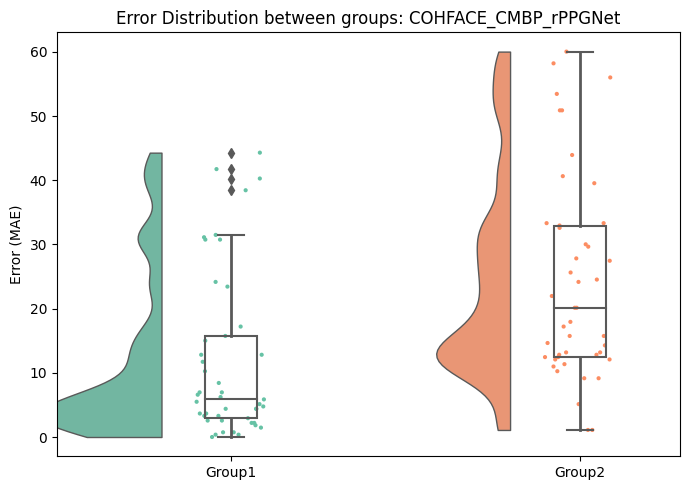

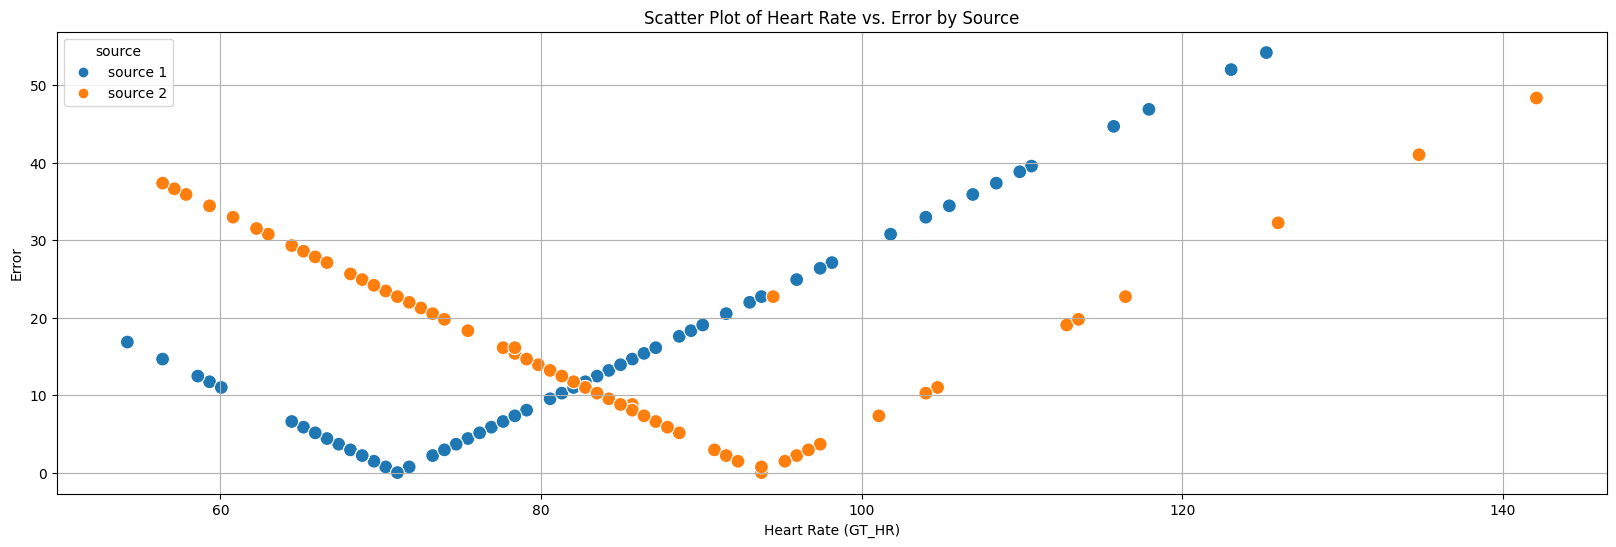

No. of Participants in dataset:  45


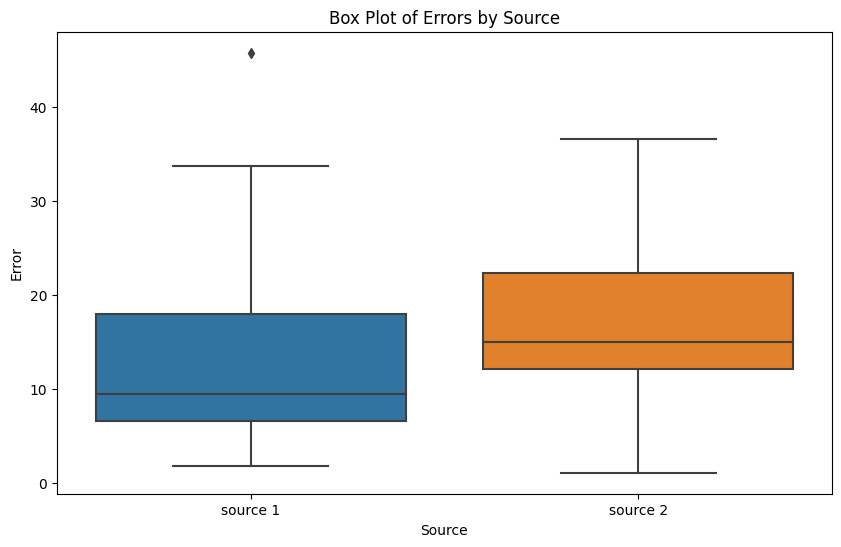

No significant difference detected between scenarios.


/Users/bhargavacharya/miniconda3/envs/stats/lib/python3.10/site-packages/seaborn/_core.py:1462: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/Users/bhargavacharya/miniconda3/envs/stats/lib/python3.10/site-packages/seaborn/_core.py:1462: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/Users/bhargavacharya/miniconda3/envs/stats/lib/python3.10/site-packages/seaborn/_core.py:1462: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


,0,1,2
0,Illumination_metrics(model='PURE_CMBP_DeepPhys...,0 0.732422 1 1.831055 2 3.662109 3...,0 0.000000 1 0.366211 2 0.73242...
1,"Illumination_metrics(model='PURE_CMBP_Tscan', ...",0 0.000000 1 0.000000 2 0.366211 3...,0 0.366211 1 0.732422 2 0.366211 3...
2,Illumination_metrics(model='PURE_CMBP_Physnet'...,0 10.986328 1 9.887695 2 32.22656...,0 11.718750 1 20.874023 2 27.09960...
3,Illumination_metrics(model='COHFACE_CMBP_DeepP...,0 0.732422 1 13.916016 2 26.36718...,0 1.098633 1 1.098633 2 21.97265...
4,Illumination_metrics(model='COHFACE_CMBP_Tscan...,0 0.732422 1 1.831055 2 1.098633 3...,0 0.732422 1 1.098633 2 1.098633 3...
5,Illumination_metrics(model='COHFACE_CMBP_Physn...,0 5.859375 1 24.536133 2 20.14160...,0 0.366211 1 0.366211 2 0.36621...
6,Illumination_metrics(model='COHFACE_CMBP_rPPGN...,0 2.563477 1 11.718750 2 1.46484...,0 24.536133 1 15.747070 2 12.45117...
7,Illumination_metrics(model='PURE_CMBP_rPPGNet'...,0 7.324219 1 29.663086 2 27.46582...,0 14.282227 1 4.028320 2 1.09863...


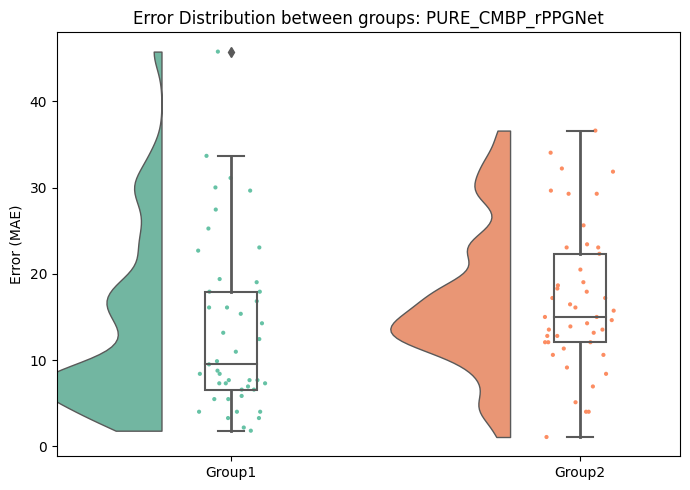

In [39]:
results_CMBP = []
dataset = "CHILL"

for model_name, model in model_dataframes.items():

    print(model_name)
    chill_statistical_tests = mbp_datasets_statistical_tests(model, model_name, dataset, save_dir="/Users/bhargavacharya/phd_projects/statistical_analysis/generalization/illu/")
    results_CMBP.append(chill_statistical_tests.paired_wilcoxen_test_on_illumination_groups(plot=True))

wilcoxen_illu_generalization_results = pd.DataFrame(results_CMBP)
wilcoxen_illu_generalization_results.to_csv("wilcoxen_illu_generalization_results")
wilcoxen_illu_generalization_results

In [22]:
import utils
from importlib import reload
reload(utils)
from utils import *

In [23]:
# models = [ deepPhys_CMBP_df, tscan_CMBP_df, physnet_CMBP_df, rppgnet_CMBP_df ]
# model_names = ["deepPhys", "tscan", "physnet", "rppgnet"]

results_CMBP = []
dataset = "CHILL"

for model_name, model in model_dataframes.items():

    chill_statistical_tests = mbp_datasets_statistical_tests(model, model_name, dataset)
    results_CMBP.append(chill_statistical_tests.paired_wilcoxen_test_on_hr_groups(plot=False))

wilcoxen_hr_generalization_results = pd.DataFrame(results_CMBP)
wilcoxen_hr_generalization_results.to_csv("wilcoxen_hr_generalization_results")
wilcoxen_hr_generalization_results

using chill dataset
defining scenarios
This is performed on hr splits
No. of Participants in dataset:  21
No significant difference detected between scenarios.


,model,test_Used,t_statistic,p_value,effect_size_r,highhr_median,lowhr_median,delta_median
0,PURE_CMBP_rPPGNet,Wilcoxon Signed-Rank Test,110.0,0.848361,-0.041716,10.986328,12.084961,1.098633


In [24]:
results_CMBP = []
dataset = "CHILL"

for model_name, model in model_dataframes.items():

    chill_statistical_tests = mbp_datasets_statistical_tests(model, model_name, dataset)
    results_CMBP.append(chill_statistical_tests.paired_less_wilcoxen_test_on_illumination_groups(plot=False))

wilcoxen_less_illu_generalization_results = pd.DataFrame(results_CMBP)
wilcoxen_less_illu_generalization_results.to_csv("wilcoxen_less_illu_generalization_results")
wilcoxen_less_illu_generalization_results

using chill dataset
defining scenarios
This is performed on illumination splits
No. of Participants in dataset:  45
Significant difference detected between scenarios!


,model,test_Used,t_statistic,p_value,effect_size_r,dark_median,bright_median,delta_median
0,PURE_CMBP_rPPGNet,Wilcoxon Signed-Rank Test,366.0,0.043608,-0.254921,15.014648,9.521484,-5.493164


using chill dataset
defining scenarios
This is performed on hr splits
No. of Participants in dataset:  21


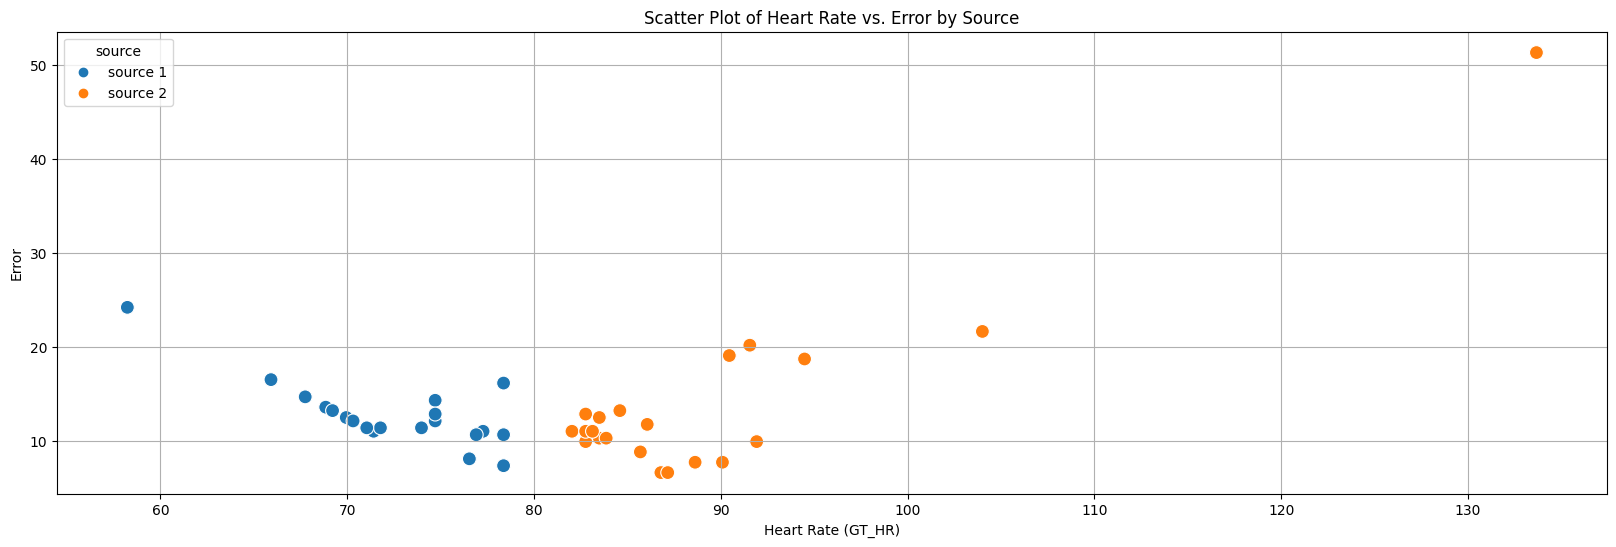

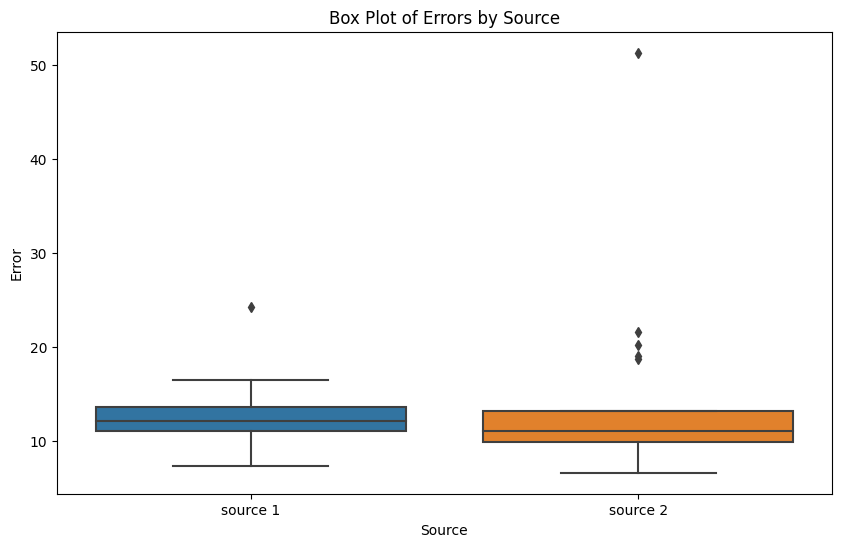

No significant difference detected between scenarios.


/Users/bhargavacharya/miniconda3/envs/stats/lib/python3.10/site-packages/seaborn/_core.py:1462: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/Users/bhargavacharya/miniconda3/envs/stats/lib/python3.10/site-packages/seaborn/_core.py:1462: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/Users/bhargavacharya/miniconda3/envs/stats/lib/python3.10/site-packages/seaborn/_core.py:1462: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


,0,1,2
0,"HR_metrics(model='PURE_CMBP_rPPGNet', test_Use...",0 8.056641 1 10.620117 2 12.45117...,0 12.817383 1 19.042969 2 21.60644...


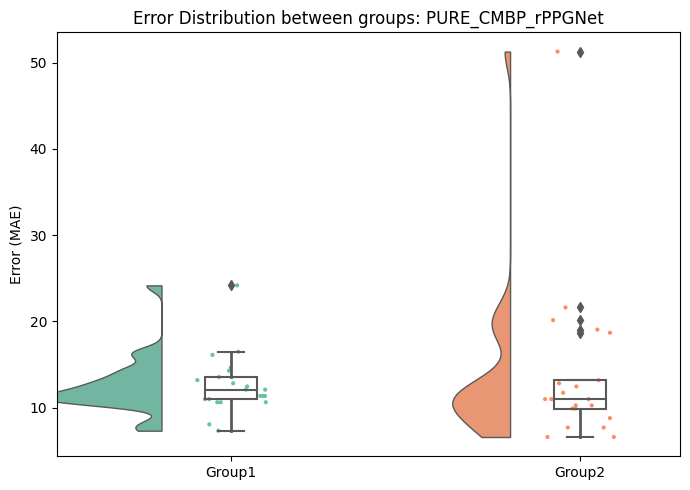

In [25]:
results_CMBP = []
dataset = "CHILL"

for model_name, model in model_dataframes.items():

    chill_statistical_tests = mbp_datasets_statistical_tests(model, model_name, dataset, save_dir="/Users/bhargavacharya/phd_projects/statistical_analysis/generalization/hr/")
    results_CMBP.append(chill_statistical_tests.paired_less_wilcoxen_test_on_hr_groups(plot=True))

wilcoxen_less_hr_generalization_results = pd.DataFrame(results_CMBP)
wilcoxen_less_hr_generalization_results.to_csv("wilcoxen_less_hr_generalization_results")
wilcoxen_less_hr_generalization_results

In [48]:
key_order = ['PURE_CMBP_DeepPhys', 'COHFACE_CMBP_DeepPhys', 'PURE_CMBP_Tscan', 'COHFACE_CMBP_Tscan',  'PURE_CMBP_Physnet',  'COHFACE_CMBP_Physnet','PURE_CMBP_rPPGNet', 'COHFACE_CMBP_rPPGNet' ]

ordered_models = OrderedDict()
for k in key_order:
    ordered_models[k] = model_dataframes[k]

In [49]:
results = mbp_datasets_statistical_tests.batch_process_models(ordered_models, "CHILL")

using chill dataset
defining scenarios
This is performed on illumination splits
No. of Participants in dataset:  45
No significant difference detected between scenarios.
This is performed on hr splits
No. of Participants in dataset:  21
Significant difference detected between scenarios!
using chill dataset
defining scenarios
This is performed on illumination splits
No. of Participants in dataset:  45
No significant difference detected between scenarios.
This is performed on hr splits
No. of Participants in dataset:  21
Significant difference detected between scenarios!
using chill dataset
defining scenarios
This is performed on illumination splits
No. of Participants in dataset:  45
No significant difference detected between scenarios.
This is performed on hr splits
No. of Participants in dataset:  21
Significant difference detected between scenarios!
using chill dataset
defining scenarios
This is performed on illumination splits
No. of Participants in dataset:  45
No significant diffe

In [50]:
illumetrics = []
hr_metrics = []
for model_name in results.keys():
    illumetrics.append(results[model_name]['illumination']['metrics'])
    hr_metrics.append(results[model_name]['HR']['metrics'])

In [51]:
pd.DataFrame(illumetrics)

,model,test_Used,t_statistic,p_value,effect_size_r,dark_median,bright_median,delta_median
0,PURE_CMBP_DeepPhys,Wilcoxon Signed-Rank Test,304.0,0.854541,-0.359246,0.732422,0.732422,0.000000
1,COHFACE_CMBP_DeepPhys,Wilcoxon Signed-Rank Test,249.0,0.398372,-0.451791,0.732422,1.098633,0.000000
2,PURE_CMBP_Tscan,Wilcoxon Signed-Rank Test,381.5,0.904776,-0.228840,0.732422,0.732422,0.000000
3,COHFACE_CMBP_Tscan,Wilcoxon Signed-Rank Test,149.0,0.215584,-0.620056,0.732422,1.098633,0.000000
4,PURE_CMBP_Physnet,Wilcoxon Signed-Rank Test,348.0,0.130948,-0.285209,11.718750,13.183594,1.098633
5,COHFACE_CMBP_Physnet,Wilcoxon Signed-Rank Test,123.5,0.000009,-0.662964,1.098633,8.056641,5.859375
6,PURE_CMBP_rPPGNet,Wilcoxon Signed-Rank Test,366.0,0.087216,-0.254921,15.014648,9.521484,-5.493164
7,COHFACE_CMBP_rPPGNet,Wilcoxon Signed-Rank Test,170.5,0.000090,-0.583879,20.141602,5.859375,-10.986328


In [52]:
pd.DataFrame(hr_metrics)

,model,test_Used,t_statistic,p_value,effect_size_r,highhr_median,lowhr_median,delta_median
0,PURE_CMBP_DeepPhys,Wilcoxon Signed-Rank Test,21.0,0.003984,-0.716758,0.732422,0.366211,-0.366211
1,COHFACE_CMBP_DeepPhys,Wilcoxon Signed-Rank Test,3.0,0.000357,-0.853283,1.464844,0.366211,-0.732422
2,PURE_CMBP_Tscan,Wilcoxon Signed-Rank Test,47.0,0.024593,-0.519555,0.732422,0.732422,-0.366211
3,COHFACE_CMBP_Tscan,Wilcoxon Signed-Rank Test,11.0,0.001554,-0.792605,1.098633,0.732422,-0.732422
4,PURE_CMBP_Physnet,Wilcoxon Signed-Rank Test,0.0,0.000030,-0.876038,19.042969,6.225586,-13.549805
5,COHFACE_CMBP_Physnet,Wilcoxon Signed-Rank Test,38.0,0.006172,-0.587817,5.493164,1.831055,-4.028320
6,PURE_CMBP_rPPGNet,Wilcoxon Signed-Rank Test,121.0,0.575820,0.041716,10.986328,12.084961,1.098633
7,COHFACE_CMBP_rPPGNet,Wilcoxon Signed-Rank Test,179.0,0.986353,0.481631,10.253906,16.113281,10.253906


In [56]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def extract_data(data, scenario, series_labels):
    rows = []
    for model_fullname, model_data in data.items():
        parts = model_fullname.split('_')
        print(parts)
        dataset = parts[0] if len(parts) > 0 else 'Unknown'
        arch = parts[-1]

        scenario_data = model_data[scenario]
        for label in series_labels:
            values = scenario_data[label]
            for v in values:
                rows.append({
                    'Model': model_fullname,
                    'Architecture': arch,
                    'Dataset': dataset,
                    'Dataset_Prefix': dataset,
                    'Condition': label,
                    'Error': v,
                    'p_value': scenario_data['metrics'].p_value
                })
    return pd.DataFrame(rows)

def plot_with_significance(df, title, y_offset=5, save_path=None):
    plt.figure(figsize=(12, 16))

    point_palette = {
        'Bright': '#FFCCCC',
        'Dark': '#CCE5FF',
        'Low-HR': '#CCE5CC',
        'High-HR': '#FFB3B3'
    }

    # Combine Architecture and Dataset_Prefix for the x-axis grouping
    df['Group'] = df['Architecture'] + ' - ' + df['Dataset_Prefix']

    ax = plt.gca()

    sns.boxplot(
        x='Group', y='Error', hue='Condition', data=df, palette='light:#d3d3d3',
        boxprops={'facecolor': 'none'}, showcaps=True, medianprops={'color': 'black'},
        flierprops={'marker': 'o', 'markerfacecolor': 'gray', 'alpha': 0.3},
        ax=ax, dodge=True
    )

    # Overlay stripplot points
    sns.stripplot(
        x='Group', y='Error', hue='Condition', data=df, dodge=True,
        palette=point_palette, alpha=0.6, size=5, linewidth=0.8, edgecolor='black', ax=ax
    )

    # Legend
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), title='Condition', loc='upper left')

    # Significance annotations (will require adjustment based on the new x-axis)
    groups = df['Group'].unique()
    for i, group in enumerate(groups):
        group_df = df[df['Group'] == group]
        # You'll need to adjust the logic here to find the max error and p_value
        # for the correct comparisons you want to annotate.
        # This example assumes you want to annotate significance across all conditions
        # within each group.

        y_max = group_df['Error'].max()
        # Assuming p_value is the same for all within the group for a given scenario
        p_val = group_df['p_value'].values[0] if not group_df.empty else None

        if p_val is not None:
            if p_val < 0.005:
                sig_label = "**"
            elif p_val < 0.05:
                sig_label = "*"
            else:
                sig_label = "n.s."

            if sig_label:
                # Approximate x positions for the significance bar (center of the group)
                x_pos = i
                y = y_max + y_offset
                h = y_offset * 0.4

                ax.plot([x_pos - 0.2, x_pos - 0.2, x_pos + 0.2, x_pos + 0.2], [y, y + h, y + h, y], lw=1.5, c='black')
                ax.text(x_pos, y + h + 0.5, sig_label, ha='center', va='bottom', color='black', fontsize=14)


    # X-axis labels
    ax.set_xlabel('Architecture - Dataset', fontsize=12)
    ax.set_ylabel('Error', fontsize=12)
    plt.xticks(rotation=45, ha='right')

    # plt.title(title, fontsize=14)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    plt.show()

In [62]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def extract_data(data, scenario, series_labels):
    rows = []
    for model_fullname, model_data in data.items():
        parts = model_fullname.split('_')
        print(parts)
        dataset = parts[0] if len(parts) > 0 else 'Unknown'
        arch = parts[-1]

        scenario_data = model_data[scenario]
        for label in series_labels:
            values = scenario_data[label]
            for v in values:
                rows.append({
                    'Model': model_fullname,
                    'Architecture': arch,
                    'Dataset': dataset,
                    'Dataset_Prefix': dataset,
                    'Condition': label,
                    'Error': v,
                    'p_value': scenario_data['metrics'].p_value
                })
    return pd.DataFrame(rows)

# -- Plotting function with simulated broken axis using subplots --
def plot_with_significance(df, title, y_offset=5, save_path=None, lims=None):

    label_size = 16
    # Set default limits if none provided
    if lims is None:
        lims = ((0, 15), (65, 75))
    
    # Light color palette for points
    point_palette = {
        'Bright': '#FFCCCC',  # Light red
        'Dark': '#CCE5CC',    # Light green
        'Low-HR': '#CCE5CC',   # Light green
        'High-HR': '#FFB3B3'   # Light red
    }
    
    # Set seaborn context
    sns.set_context("paper", rc={"font.size": 24, "axes.labelsize": 5})   
    
    # Create figure with two subplots (top and bottom)
    fig, (ax_top, ax_bottom) = plt.subplots(2, 1, figsize=(14, 10), 
                                           gridspec_kw={'height_ratios': [1, 2], 'hspace': 0.05}, dpi=600)
    
    df['Group'] = df['Architecture'] + ' - ' + df['Dataset_Prefix']

    # Plot on top subplot (upper range)
    sns.boxplot(
        x='Group', 
        y='Error', 
        hue='Condition', 
        data=df, 
        palette='light:#d3d3d3', 
        width=0.6, 
        boxprops={'facecolor': 'none'}, 
        showcaps=True, 
        medianprops={'color': 'black'}, 
        fliersize=0.0,
        ax=ax_top
    )
    
    sns.stripplot(
        x='Group', 
        y='Error', 
        hue='Condition', 
        data=df, 
        dodge=True,
        jitter=0.2,
        palette=point_palette,
        alpha=0.6,
        size=4,
        linewidth=0.8,
        edgecolor='black',
        ax=ax_top
    )
    
    # Plot on bottom subplot (lower range)
    sns.boxplot(
        x='Group', 
        y='Error', 
        hue='Condition', 
        data=df, 
        palette='light:#d3d3d3', 
        width=0.6, 
        boxprops={'facecolor': 'none'}, 
        showcaps=True, 
        medianprops={'color': 'black'}, 
        fliersize=0.0,
        ax=ax_bottom
    )
    
    sns.stripplot(
        x='Group', 
        y='Error', 
        hue='Condition', 
        data=df, 
        dodge=True,
        jitter=0.2,
        palette=point_palette,
        alpha=0.6,
        size=4,
        linewidth=0.8,
        edgecolor='black',
        ax=ax_bottom
    )
    
    # Set y-axis limits for each subplot
    ax_top.set_ylim(lims[1])    # Upper range
    ax_bottom.set_ylim(lims[0]) # Lower range
    
    # Hide x-axis labels and ticks for top plot
    ax_top.set_xlabel('')
    ax_top.set_xticklabels([])
        
    ax_top.set_ylabel('')
    # ax_top.set_ylim(lims[1])
    ax_top.yaxis.set_major_locator(plt.MultipleLocator(5)) 
    ax_top.set_ylim(top=lims[1][1] + 2)
    # ax_top.set_ylim(top=lims[1][0] - 1)


    ax_top.tick_params(axis='x', which='both', bottom=False, top=False)
    
    # Set tick parameters
    ax_top.tick_params(axis='y', labelsize=12)
    ax_bottom.tick_params(axis='x', labelsize=12)
    ax_bottom.tick_params(axis='y', labelsize=12)
    ax_bottom.yaxis.set_major_locator(plt.MultipleLocator(5)) 
    ax_bottom.tick_params(axis='x', which='both', bottom=False, top=False, labelsize=label_size)

    ax_bottom.set_ylabel('')
    ax_bottom.set_ylim(bottom=lims[0][0] - 1) 
    # ax_bottom.set_ylim(bottom=lims[0][1] + 1) 

    # Handle legends - remove from top, keep only on bottom
    
    handles, labels = ax_top.get_legend_handles_labels()
    n_conditions = len(df['Condition'].unique())
    ax_top.legend(handles[-n_conditions:], labels[-n_conditions:], 
                    title='Condition')
    ax_bottom.legend().remove()
    
    # Add significance annotations - always visible
    models = df['Model'].unique()
    for i, model in enumerate(models):
        model_df = df[df['Model'] == model]
        y_max = model_df['Error'].max()
        p_val = model_df['p_value'].values[0]
        
        # Significance stars
        if p_val < 0.001:
            sig_label = "***"
        elif p_val < 0.01:
            sig_label = "**"
        elif p_val < 0.05:
            sig_label = "*"
        else:
            sig_label = "n.s."
        
        if sig_label != "n.s.":
            x1 = i - 0.2
            x2 = i + 0.2
            y = y_max + y_offset
            h = y_offset * 0.4
            
            # Determine which subplot(s) to use based on y position and ranges
            bottom_range = lims[0]
            top_range = lims[1]
            
            # Check if significance line fits in bottom subplot
            if y <= bottom_range[1]:
                # Line fits in bottom subplot
                ax = ax_bottom
                ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.5, c='black')
                ax.text((x1 + x2) / 2, y + h + 0.5, sig_label, ha='center', va='bottom', 
                       color='black', fontsize=label_size)
            
            # Check if significance line fits in top subplot  
            elif y >= top_range[0]:
                # Line fits in top subplot
                ax = ax_top
                ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.5, c='black')
                ax.text((x1 + x2) / 2, y + h + 0.5, sig_label, ha='center', va='bottom', 
                       color='black', fontsize=label_size)
            
            else:
                # Significance line would be in the gap - place it at top of bottom subplot
                # or bottom of top subplot, whichever is closer to the data
                bottom_distance = abs(y - bottom_range[1])
                top_distance = abs(y - top_range[0])
                
                if bottom_distance <= top_distance:
                    # Place at top of bottom subplot
                    ax = ax_bottom
                    y_pos = bottom_range[1] - (y_offset + h + 1)  # Position near top of bottom subplot
                    ax.plot([x1, x1, x2, x2], [y_pos, y_pos + h, y_pos + h, y_pos], lw=1.5, c='black')
                    ax.text((x1 + x2) / 2, y_pos + h + 0.5, sig_label, ha='center', va='bottom', 
                           color='black', fontsize=label_size)
                else:
                    # Place at bottom of top subplot
                    ax = ax_top
                    y_pos = top_range[0] + y_offset  # Position near bottom of top subplot
                    ax.plot([x1, x1, x2, x2], [y_pos, y_pos + h, y_pos + h, y_pos], lw=1.5, c='black')
                    ax.text((x1 + x2) / 2, y_pos + h + 0.5, sig_label, ha='center', va='bottom', 
                           color='black', fontsize=label_size)
    
    # Customize spines to create broken axis effect
    ax_top.spines['bottom'].set_visible(False)
    ax_bottom.spines['top'].set_visible(False)
    
    # # # Add diagonal lines to indicate break
    # d = 0.015  # Size of diagonal lines
    # kwargs = dict(transform=ax_top.transAxes, color='k', clip_on=False)
    # ax_top.plot((-d, +d), (-d, +d), **kwargs)        # top-left diagonal
    # ax_top.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # top-right diagonal
    
    # d = 0.015  # Size of diagonal lines

    # kwargs.update(transform=ax_bottom.transAxes)  # switch to bottom axes
    # ax_bottom.plot((-d, +d), (1 - d, 1 + d), **kwargs)   # bottom-left diagonal
    # ax_bottom.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # bottom-right diagonal


    d = 0.010  # Diagonal length in figure coordinates

    # Convert axes coordinates to figure coordinates
    fig_coords = fig.transFigure
    
    kwargs_top = dict(transform=fig_coords, color='k', clip_on=False)
    kwargs_bottom = dict(transform=fig_coords, color='k', clip_on=False)
    
    # Get bounding boxes for axes in figure coordinates
    bbox_top = ax_top.get_position()
    bbox_bottom = ax_bottom.get_position()
    
    # Top diagonals
    ax_top.plot(
        [bbox_top.x0 - d, bbox_top.x0 + d],
        [bbox_top.y0 - d, bbox_top.y0 + d],
        **kwargs_top
    )
    ax_top.plot(
        [bbox_top.x1- d, bbox_top.x1 + d],
        [bbox_top.y0 -d , bbox_top.y0 +d ],
        **kwargs_top
    )
    
    # Bottom diagonals
    ax_bottom.plot(
        [bbox_bottom.x0-d, bbox_bottom.x0 + d],
        [bbox_bottom.y1 -d , bbox_bottom.y1 + d],
        **kwargs_bottom
    )
    ax_bottom.plot(
        [bbox_bottom.x1 - d, bbox_bottom.x1 +d ],
        [bbox_bottom.y1 -d , bbox_bottom.y1 +d ],
        **kwargs_bottom
    )
    
    # Set labels
    ax_bottom.set_xlabel('Model', fontsize=label_size + 2)
    fig.text(0.04, 0.5, 'Error', va='center', rotation='vertical', fontsize=label_size+2)
    plt.xticks(rotation=45, ha='right')

    # Set title
    # if title:
    #     fig.suptitle(title, fontsize=18, y=0.98)
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()

['PURE', 'CMBP', 'DeepPhys']
['COHFACE', 'CMBP', 'DeepPhys']
['PURE', 'CMBP', 'Tscan']
['COHFACE', 'CMBP', 'Tscan']
['PURE', 'CMBP', 'Physnet']
['COHFACE', 'CMBP', 'Physnet']
['PURE', 'CMBP', 'rPPGNet']
['COHFACE', 'CMBP', 'rPPGNet']
['PURE', 'CMBP', 'DeepPhys']
['COHFACE', 'CMBP', 'DeepPhys']
['PURE', 'CMBP', 'Tscan']
['COHFACE', 'CMBP', 'Tscan']
['PURE', 'CMBP', 'Physnet']
['COHFACE', 'CMBP', 'Physnet']
['PURE', 'CMBP', 'rPPGNet']
['COHFACE', 'CMBP', 'rPPGNet']


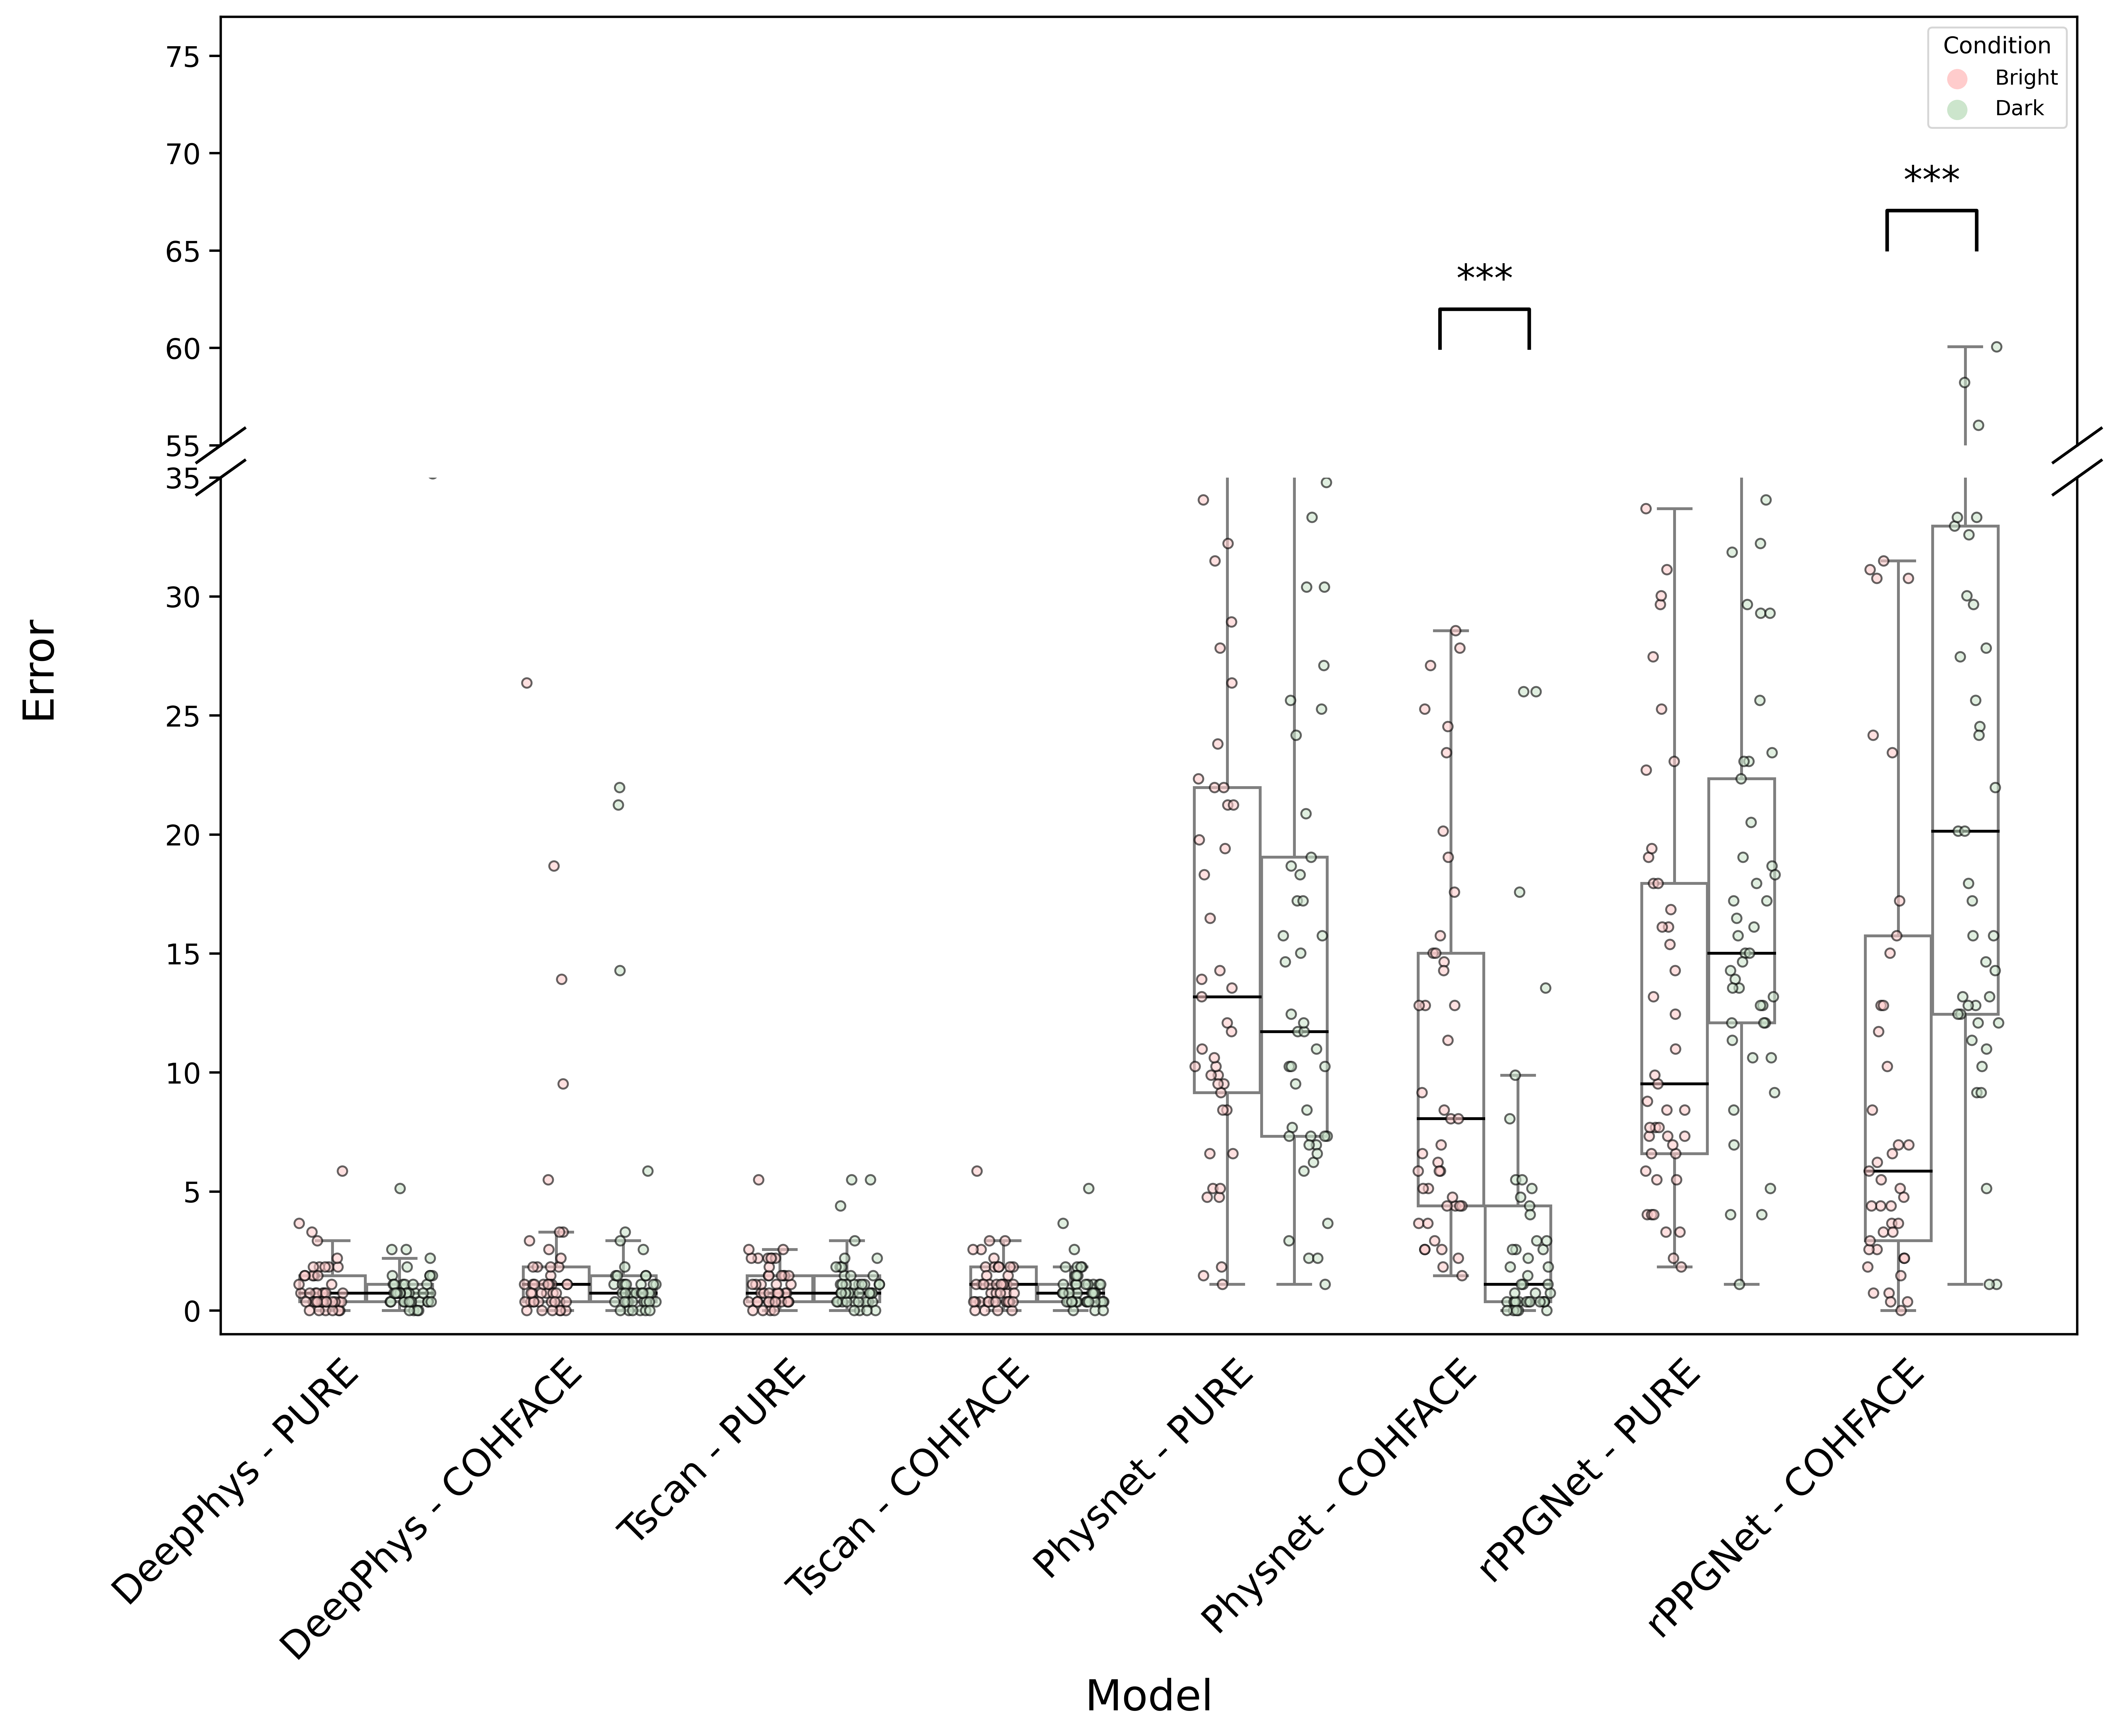

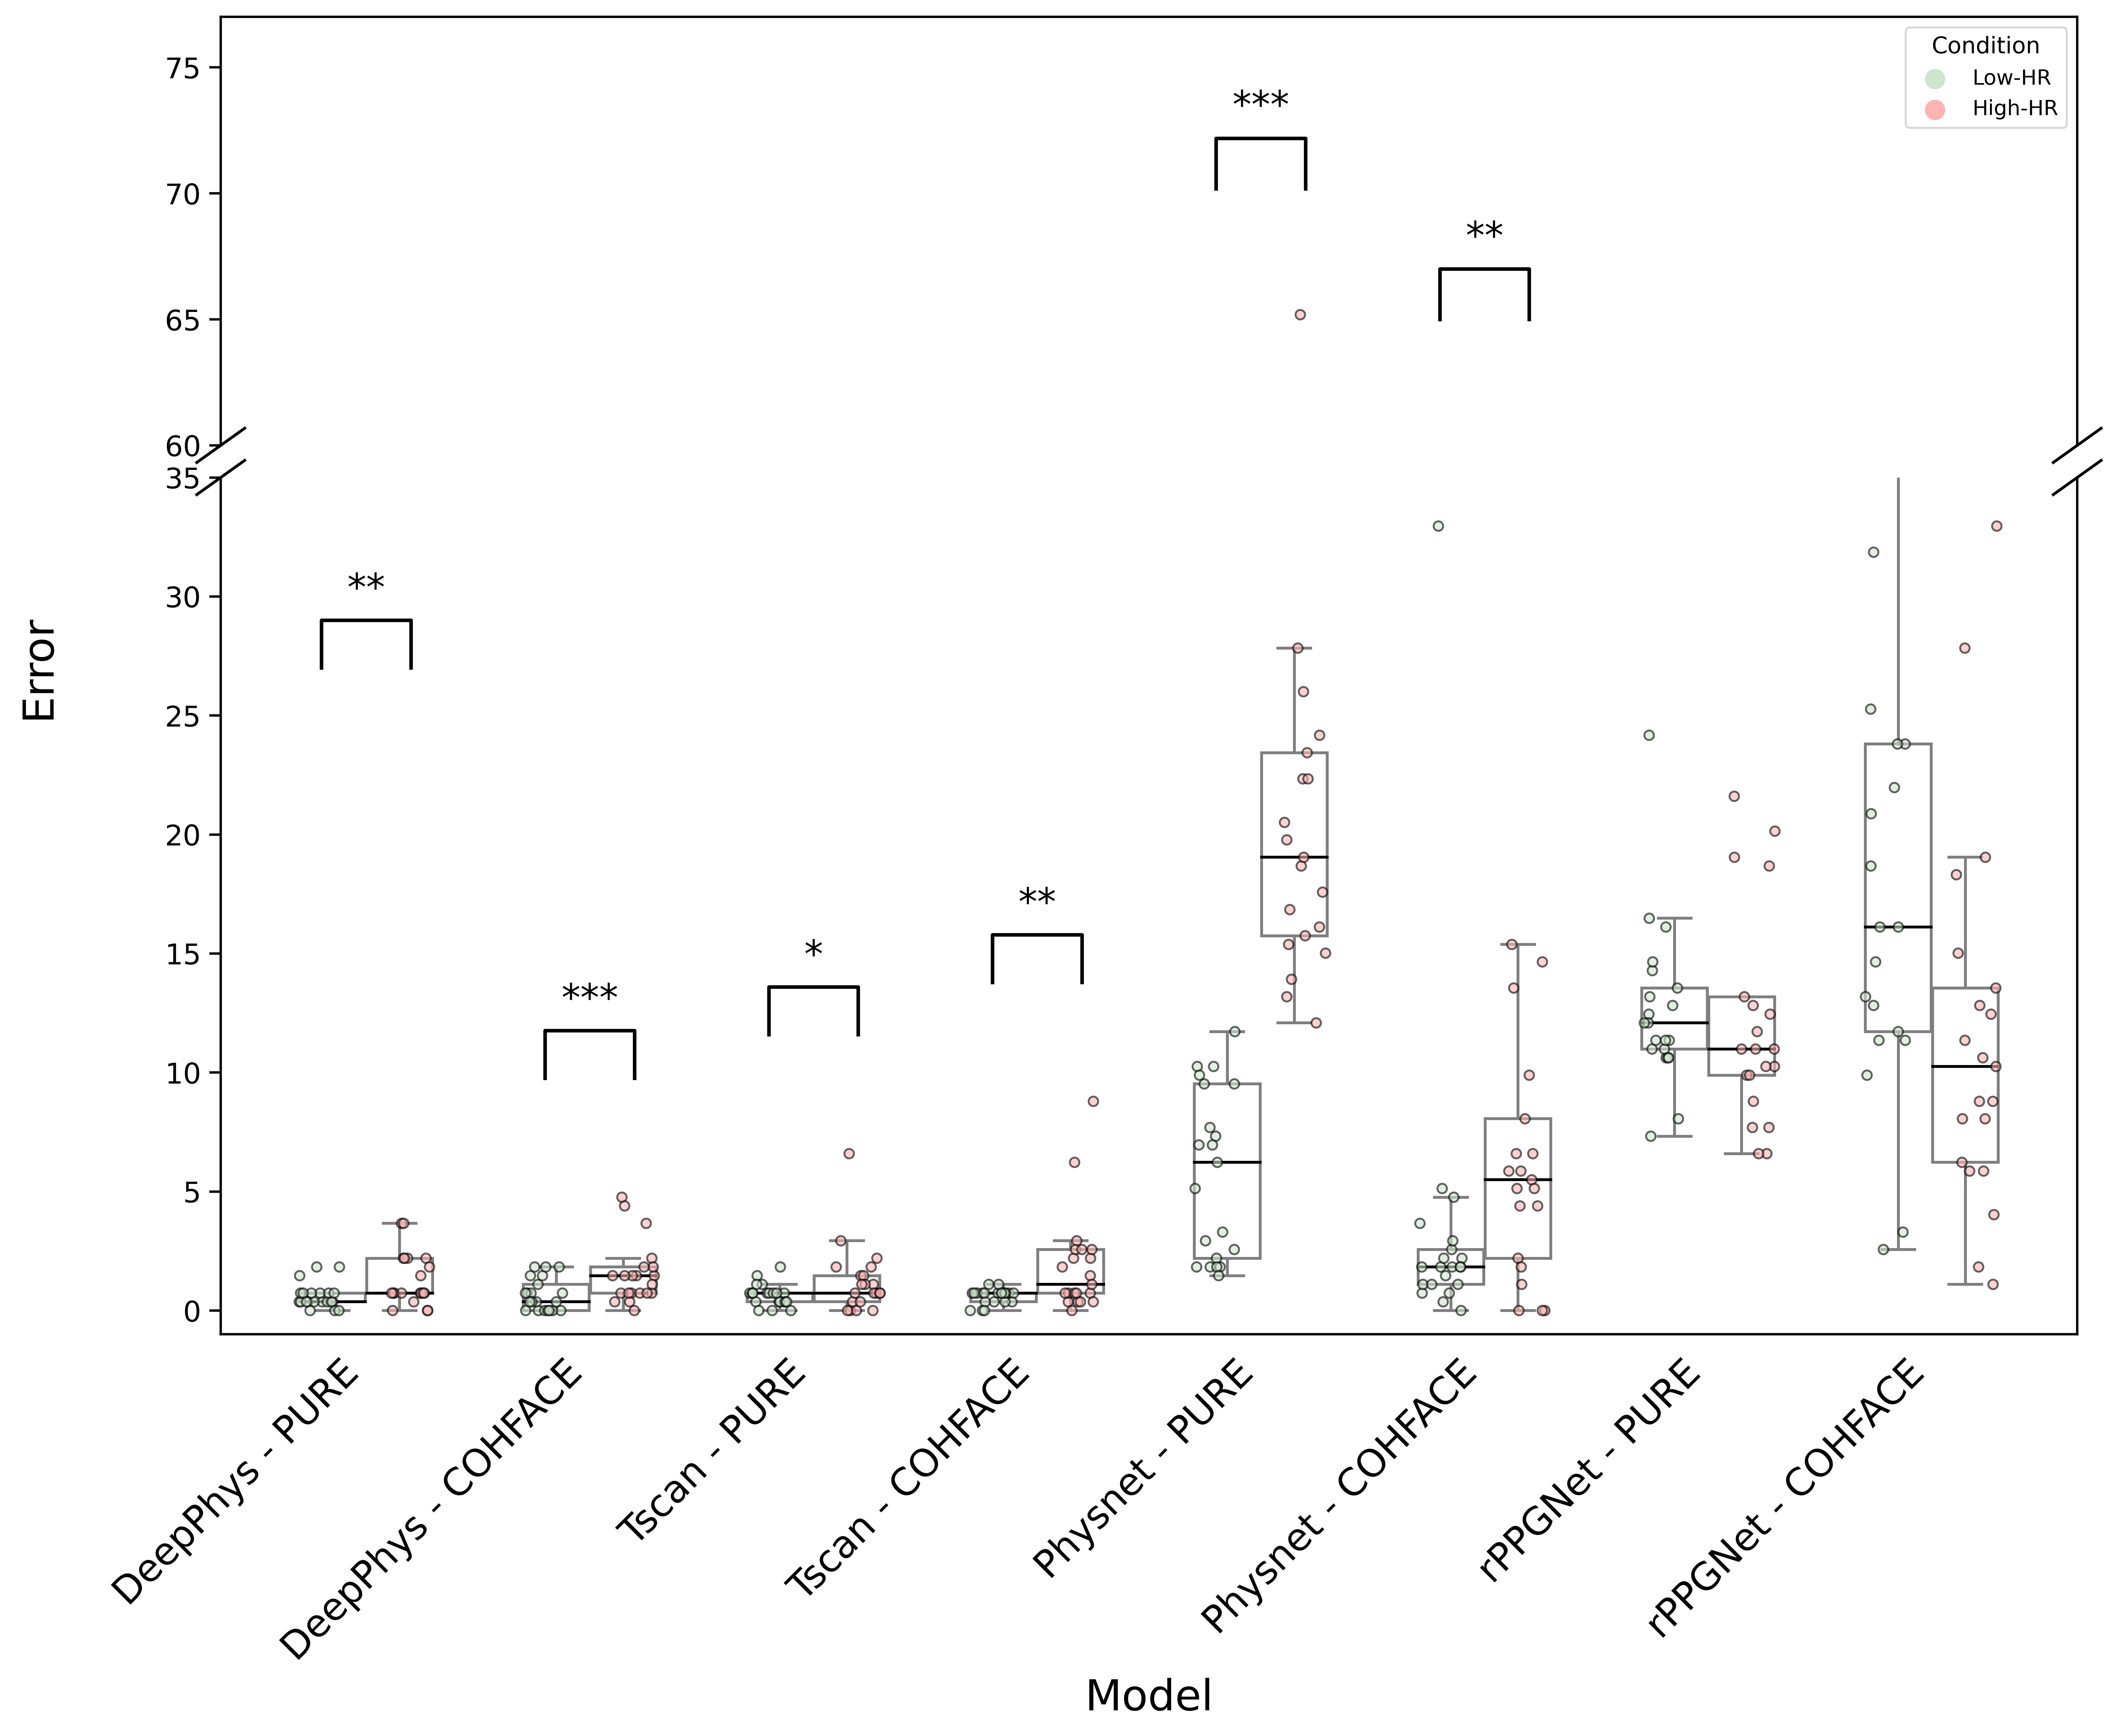

In [65]:
illum_df = extract_data(results, 'illumination', ['Bright', 'Dark'])
hr_df = extract_data(results, 'HR', [ 'Low-HR', 'High-HR'])
# Plot both
plot_with_significance(illum_df, 'Illumination Scenario', save_path="./Illumination_generalization_grouped", lims = ((0,35), (55,75)))
plot_with_significance(hr_df, 'Heart Rate Scenario', save_path="./HR_generalization_grouped", lims = ((0,35), (60,75)))

In [66]:
results

{'PURE_CMBP_DeepPhys': {'illumination': {'metrics': Illumination_metrics(model='PURE_CMBP_DeepPhys', test_Used='Wilcoxon Signed-Rank Test', t_statistic=304.0, p_value=0.8545414756186748, effect_size_r=-0.3592455311706011, dark_median=0.732421875, bright_median=0.732421875, delta_median=0.0),
   'Bright': 0     0.732422
   1     0.732422
   2     0.366211
   3     0.366211
   4     0.000000
   5     0.366211
   6     3.662109
   7     0.366211
   8     0.366211
   9     0.366211
   10    1.464844
   11    0.000000
   12    1.464844
   13    2.197266
   14    0.366211
   15    1.464844
   16    0.000000
   17    0.732422
   18    0.732422
   19    0.732422
   20    0.366211
   21    2.929688
   22    5.859375
   23    0.366211
   24    3.295898
   25    0.366211
   26    1.831055
   27    0.732422
   28    1.464844
   29    0.000000
   30    0.366211
   31    0.366211
   32    0.000000
   33    0.732422
   34    1.098633
   35    0.366211
   36    1.831055
   37    0.000000
   38    1.83